In [1]:
!pip install numpy scipy seaborn -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import json

from dataclasses import dataclass
from pathlib import Path

In [3]:
try:
    df = pd.read_csv("../data.csv")
except Exception as e:
    print("Error reading the data source file: e")
    quit()

df.head(3)

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [4]:
df.columns = [
    "id",
    "diagnostic",

    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_largest",
    "texture_largest",
    "perimeter_largest",
    "area_largest",
    "smoothness_largest",
    "compactness_largest",
    "concavity_largest",
    "concave_points_largest",
    "symmetry_largest",
    "fractal_dimension_largest",
]

df.head(3)

,id,diagnostic,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_points_largest,symmetry_largest,fractal_dimension_largest
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [5]:
df = df.drop(['id'], axis=1)
df.head(3)

,diagnostic,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_points_largest,symmetry_largest,fractal_dimension_largest
0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [6]:
df['diagnostic'] = df['diagnostic'].str.replace("B", "0")
df['diagnostic'] = df['diagnostic'].str.replace("M", "1")
df['diagnostic'] = pd.to_numeric(df['diagnostic'])
df.head(3)

,diagnostic,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_points_largest,symmetry_largest,fractal_dimension_largest
0,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300


In [7]:
df.shape

(568, 31)

In [8]:
df = df.drop_duplicates()

df = df.dropna()

df = df[(df.iloc[:,1:] != 0.0).all(axis=1)]

df.shape

(555, 31)

In [9]:
diagnostic_corr = df.corr()['diagnostic']
diagnostic_corr

diagnostic                   1.000000
radius_mean                  0.727121
texture_mean                 0.441070
perimeter_mean               0.739902
area_mean                    0.703973
smoothness_mean              0.352927
compactness_mean             0.588756
concavity_mean               0.690422
concave_points_mean          0.773487
symmetry_mean                0.329845
fractal_dimension_mean      -0.012659
radius_se                    0.566943
texture_se                   0.029666
perimeter_se                 0.554318
area_se                      0.543716
smoothness_se               -0.051925
compactness_se               0.279776
concavity_se                 0.238320
concave_points_se            0.392658
symmetry_se                  0.012723
fractal_dimension_se         0.075904
radius_largest               0.773461
texture_largest              0.472906
perimeter_largest            0.780380
area_largest                 0.728794
smoothness_largest           0.415887
compactness_

In [10]:
diagnostic_corr.sort_values(ascending=False).head(10)

diagnostic                1.000000
concave_points_largest    0.796041
perimeter_largest         0.780380
concave_points_mean       0.773487
radius_largest            0.773461
perimeter_mean            0.739902
area_largest              0.728794
radius_mean               0.727121
area_mean                 0.703973
concavity_mean            0.690422
Name: diagnostic, dtype: float64

In [11]:
diagnostic_corr.sort_values().head(5)

smoothness_se            -0.051925
fractal_dimension_mean   -0.012659
symmetry_se               0.012723
texture_se                0.029666
fractal_dimension_se      0.075904
Name: diagnostic, dtype: float64

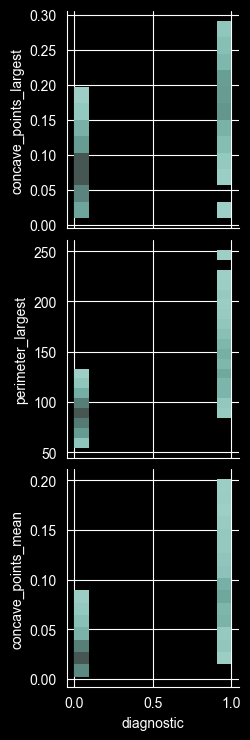

In [12]:
sns.pairplot(
    df,
    x_vars=['diagnostic'],
    y_vars=['concave_points_largest', 'perimeter_largest', 'concave_points_mean'],
    kind='hist'
)

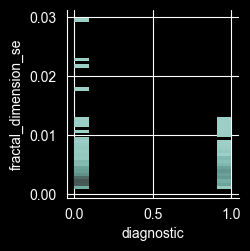

In [13]:
sns.pairplot(
    df,
    x_vars=['diagnostic'],
    y_vars=['fractal_dimension_se'],
    kind='hist'
)

In [14]:
f_df = df[['diagnostic',
        'concave_points_largest',
        'perimeter_largest',
        'concave_points_mean',
        'radius_largest',
        'perimeter_mean',
        'area_largest',
        'radius_mean',
        'area_mean',
        'concavity_mean']]

df = df[[
    "diagnostic",
    "concavity_se",
    "compactness_se",
    "fractal_dimension_largest",
    "symmetry_mean",
    "smoothness_mean",
    "concave_points_se",
    "symmetry_largest",
    "smoothness_largest",
    "texture_mean",
    "texture_largest",
    "area_se",
    "perimeter_se",
    "radius_se",
    "compactness_largest",
    "compactness_mean",
    "concavity_largest",
    "concavity_mean",
    "area_mean",
    "radius_mean",
    "area_largest",
    "perimeter_mean",
    "radius_largest",
    "concave_points_mean",
    "perimeter_largest",
    "concave_points_largest"
]]

df.head(3)


,diagnostic,concavity_se,compactness_se,fractal_dimension_largest,symmetry_mean,smoothness_mean,concave_points_se,symmetry_largest,smoothness_largest,texture_mean,...,concavity_largest,concavity_mean,area_mean,radius_mean,area_largest,perimeter_mean,radius_largest,concave_points_mean,perimeter_largest,concave_points_largest
0,1,0.01860,0.01308,0.08902,0.1812,0.08474,0.01340,0.2750,0.1238,17.77,...,0.2416,0.0869,1326.0,20.57,1956.0,132.90,24.99,0.07017,158.80,0.1860
1,1,0.03832,0.04006,0.08758,0.2069,0.10960,0.02058,0.3613,0.1444,21.25,...,0.4504,0.1974,1203.0,19.69,1709.0,130.00,23.57,0.12790,152.50,0.2430
2,1,0.05661,0.07458,0.17300,0.2597,0.14250,0.01867,0.6638,0.2098,20.38,...,0.6869,0.2414,386.1,11.42,567.7,77.58,14.91,0.10520,98.87,0.2575


In [15]:
for col in df.columns:
  df.loc[:,col] = pd.to_numeric(df[col])
  df.loc[:,col] = df[col] / df[col].max()
df.head()

,diagnostic,concavity_se,compactness_se,fractal_dimension_largest,symmetry_mean,smoothness_mean,concave_points_se,symmetry_largest,smoothness_largest,texture_mean,...,concavity_largest,concavity_mean,area_mean,radius_mean,area_largest,perimeter_mean,radius_largest,concave_points_mean,perimeter_largest,concave_points_largest
0,1,0.046970,0.096603,0.429012,0.596053,0.518605,0.253836,0.414281,0.556155,0.452393,...,0.192971,0.203608,0.530188,0.731768,0.459803,0.705040,0.693396,0.348757,0.632166,0.639175
1,1,0.096768,0.295864,0.422072,0.680592,0.670747,0.389847,0.544290,0.648697,0.540988,...,0.359744,0.462512,0.481008,0.700462,0.401740,0.689655,0.653996,0.635686,0.607086,0.835052
2,1,0.142955,0.550812,0.833735,0.854276,0.872093,0.353665,1.000000,0.942498,0.518839,...,0.548642,0.565604,0.154378,0.406261,0.133451,0.411565,0.413707,0.522863,0.393591,0.884880
3,1,0.143636,0.181758,0.370024,0.595066,0.613831,0.357075,0.356131,0.617251,0.365071,...,0.319489,0.463918,0.518593,0.721807,0.370240,0.716711,0.625416,0.518390,0.605892,0.558419
4,1,0.092727,0.247046,0.599518,0.686513,0.782130,0.215382,0.600331,0.804582,0.399695,...,0.427716,0.369728,0.190764,0.442903,0.174330,0.438037,0.429245,0.402038,0.411624,0.598282


In [16]:
for col in f_df.columns:
  f_df.loc[:,col] = pd.to_numeric(f_df[col])
  f_df.loc[:,col] = f_df[col] / f_df[col].max()

In [17]:
np.random.seed(0)

mask = np.random.rand(len(df)) < 0.8

train_set = df[mask].to_numpy().astype(np.float64)
val_set = df[~mask].to_numpy().astype(np.float64)

print(len(train_set))
print(len(val_set))

450
105


In [18]:
f_train_set = f_df[mask].to_numpy().astype(np.float64)
f_val_set = f_df[~mask].to_numpy().astype(np.float64)

In [19]:
def softmax(x):
  return x / x.sum()

In [20]:
def binary_cross_entropy_error(predictions, expected):

  def f(p, y):
    return y * np.log(p) + (1 - y) * np.log(1 - p)

  loss = f(predictions, expected).sum() * -1 / len(predictions)

  return loss

In [21]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def d_sigmoid(x):
  return sigmoid(x) * (1 - sigmoid(x))


In [22]:
@dataclass
class LayerParameters:
    weights: np.ndarray
    biases: np.ndarray


class Layer:

  def __init__(self,
               parameters: LayerParameters,
               previous_layer=None):

    self.W = parameters.weights
    self.B = parameters.biases

    self.Z = None
    self.output = None
    self.C = None

    self.previous_layer = previous_layer
    if self.previous_layer:
      self.previous_layer.next_layer = self

    self.next_layer = None
    self.input = None
    self.delta = None

  def forward_pass(self, a, result=False):

    self.input = a

    self.Z = self.W @ self.input + self.B

    self.output = sigmoid(self.Z)

    if self.next_layer:
      return self.next_layer.forward_pass(self.output, result=result)

    return softmax(self.output)

  def set_delta(self, expected_y=None):

    if self.next_layer is None:
      self.delta = self.output - expected_y

    else:
      self.delta = np.transpose(self.next_layer.W) @ self.next_layer.delta * d_sigmoid(self.Z)

    if self.previous_layer:
      self.previous_layer.set_delta()

  def set_c(self):
    self.C = self.delta @ np.transpose(self.input)
    if self.previous_layer:
      self.previous_layer.set_c()

  def adjust_weights(self, lr):
    self.W = self.W - (lr * self.C)
    if self.previous_layer:
      self.previous_layer.adjust_weights(lr)

  def adjust_biases(self, lr):
      self.B = self.B - (lr * self.delta)
      if self.previous_layer:
          self.previous_layer.adjust_biases(lr)

  def get_parameters(self):
        return LayerParameters(
            self.W,
            self.B
        )

In [23]:
@dataclass
class Model:
    layers: list[LayerParameters]

    def to_struct(self):
        return {
            "layers": [
                {
                    "weights": l.weights.tolist(),
                    "biases": l.biases.tolist()
                } for l in self.layers]
        }

    def save(self, filename):
        output_file = Path(f"models/{filename}")

        if not output_file.exists():
            output_file.parent.mkdir(exist_ok=True, parents=True)

        print(f"SAVING MODEL INTO {output_file.absolute()}")

        with output_file.open('w') as f:
            json.dump(self.to_struct(), f)

@dataclass
class ModelPerformance:
    loss: float|None
    model: Model|None



In [24]:
class NeuralNetwork:

    def __init__(self, *args, model=None):
        if model:
            self.load_model(model)
            return

        if len(args) <= 1:
            raise Exception("The neural network should have at least one layer")

        self.architecture = [int(x) for x in args[1:]]

        self.layers = []

        current_layer = None
        input_count = int(args[0])
        for neurons_count in self.architecture:
            current_layer = Layer (
                LayerParameters(
                    weights=np.random.rand(neurons_count, input_count),
                    biases=np.reshape(np.zeros(neurons_count), [neurons_count, 1])
                ),
                previous_layer=current_layer,
            )
            input_count = neurons_count
            self.layers.append(current_layer)

        self.input_layer = self.layers[0]
        self.output_layer = self.layers[-1]

    def load_model(self, model: Model):

        self.layers = []
        current_layer = None
        for layer in model.layers:
            current_layer = Layer(
                parameters=layer,
                previous_layer=current_layer
            )
            self.layers.append(current_layer)

        self.input_layer = self.layers[0]
        self.output_layer = self.layers[-1]

    def init_forward_pass(self, x):
        return self.input_layer.forward_pass(x)

    def init_back_propagation(self, expected_y, lr):
        self.output_layer.set_delta(expected_y=expected_y)
        self.output_layer.set_c()
        self.output_layer.adjust_weights(lr)
        self.output_layer.adjust_biases(lr)

    def get_model(self):

        layers_params = []
        for l in self.layers:
            layers_params.append(l.get_parameters())

        return Model(
            layers_params
        )

In [25]:
@dataclass
class EpochResult:
    train_loss: float
    val_loss: float
    val_accuracy: float

def training_iteration(nn, sample, lr):

    expected_result = np.array([[sample[0]], [1 - sample[0]]])
    model_input = np.reshape(sample[1:], [len(sample) - 1, 1])

    model_output = nn.init_forward_pass(model_input)

    loss = binary_cross_entropy_error(model_output, expected_result)

    nn.init_back_propagation(expected_result, lr)

    return loss

def is_correct(expected, actual):
    return (actual[0] > actual[1]) != (expected[1] == 1)

def validation_iteration(nn, sample):
    expected_result = np.array([[sample[0]], [1 - sample[0]]])
    model_input = np.reshape(sample[1:], [len(sample) - 1, 1])

    model_output = nn.init_forward_pass(model_input)

    loss = binary_cross_entropy_error(model_output, expected_result)

    return is_correct(expected_result.flatten(), model_output.flatten()), loss


def validation_epoch(nn, test_set):

    cumulate_loss = 0
    correct_output = 0
    for sample in test_set:
        correct, loss = validation_iteration(nn, sample)
        correct_output += int(correct)
        cumulate_loss += loss

    final_accuracy = correct_output / len(test_set)
    final_loss = cumulate_loss / len(test_set)

    return final_accuracy, final_loss

def training_epoch(nn, train_set, lr):

    cumulate_loss = 0
    for sample in train_set:
        loss = training_iteration(nn, sample, lr)
        cumulate_loss += loss

    final_loss = cumulate_loss / len(train_set)

    return final_loss

def epoch(nn, train_set, val_set, lr):

    train_loss = training_epoch(nn, train_set, lr)

    val_accuracy, val_loss = validation_epoch(nn, val_set)

    return EpochResult(train_loss, val_loss, val_accuracy)

In [26]:
MAX_EPOCH = 10_000
PATIENCE = 50
WARMING_EPOCH = 100
LEARNING_RATE = 0.01

In [27]:
nn = NeuralNetwork(
    train_set.shape[1] - 1,
    16,
    8,
    2
)

best_model = ModelPerformance(
    loss=None,
    model=None
)

evolution_accuracy = []
evolution_train_loss = []
evolution_val_loss = []

p = 0
epoch_count = 0

for x in range(MAX_EPOCH):
    epoch_r = epoch(nn, train_set, val_set, LEARNING_RATE)

    epoch_count += 1

    evolution_accuracy.append(epoch_r.val_accuracy)
    evolution_train_loss.append(epoch_r.train_loss)
    evolution_val_loss.append(epoch_r.val_loss)

    if (best_model.loss is None or
            epoch_r.val_loss < best_model.loss):
        best_model.loss = epoch_r.val_loss
        best_model.model = nn.get_model()
        p = 0

    elif x > WARMING_EPOCH and epoch_r.val_loss > best_model.loss + 0.01:
        p += 1

    if p > PATIENCE:
        break

    print(f"epoch {x} - loss: {epoch_r.train_loss:.4f} - val_loss: {epoch_r.val_loss:.4f}")

print(f"BEST MODEL -- VAL LOSS {best_model.loss} -- EPOCHS RAN {epoch_count}")

epoch 0 - loss: 0.6504 - val_loss: 0.6172
epoch 1 - loss: 0.6565 - val_loss: 0.6172
epoch 2 - loss: 0.6565 - val_loss: 0.6172
epoch 3 - loss: 0.6565 - val_loss: 0.6172
epoch 4 - loss: 0.6565 - val_loss: 0.6172
epoch 5 - loss: 0.6565 - val_loss: 0.6172
epoch 6 - loss: 0.6565 - val_loss: 0.6172
epoch 7 - loss: 0.6565 - val_loss: 0.6172
epoch 8 - loss: 0.6565 - val_loss: 0.6172
epoch 9 - loss: 0.6565 - val_loss: 0.6172
epoch 10 - loss: 0.6565 - val_loss: 0.6172
epoch 11 - loss: 0.6565 - val_loss: 0.6172
epoch 12 - loss: 0.6565 - val_loss: 0.6172
epoch 13 - loss: 0.6565 - val_loss: 0.6172
epoch 14 - loss: 0.6565 - val_loss: 0.6172
epoch 15 - loss: 0.6565 - val_loss: 0.6172
epoch 16 - loss: 0.6565 - val_loss: 0.6172
epoch 17 - loss: 0.6565 - val_loss: 0.6172
epoch 18 - loss: 0.6565 - val_loss: 0.6172
epoch 19 - loss: 0.6565 - val_loss: 0.6172
epoch 20 - loss: 0.6565 - val_loss: 0.6172
epoch 21 - loss: 0.6565 - val_loss: 0.6172
epoch 22 - loss: 0.6565 - val_loss: 0.6172
epoch 23 - loss: 0.65

In [28]:
f_nn = NeuralNetwork(
    f_train_set.shape[1] - 1,
    16,
    8,
    2
)

f_best_model = ModelPerformance(
    loss=None,
    model=None
)

f_evolution_accuracy = []
f_evolution_train_loss = []
f_evolution_val_loss = []

p = 0
f_epoch_count = 0

for x in range(MAX_EPOCH):
    epoch_r = epoch(f_nn, f_train_set, f_val_set, LEARNING_RATE)

    f_epoch_count += 1

    f_evolution_accuracy.append(epoch_r.val_accuracy)
    f_evolution_train_loss.append(epoch_r.train_loss)
    f_evolution_val_loss.append(epoch_r.val_loss)

    if (f_best_model.loss is None or
            epoch_r.val_loss < f_best_model.loss):
        f_best_model.loss = epoch_r.val_loss
        f_best_model.model = f_nn.get_model()
        p = 0

    elif x > WARMING_EPOCH and epoch_r.val_loss > f_best_model.loss + 0.01:
        p += 1

    if p > PATIENCE:
        break

    print(f"epoch {x} - loss: {epoch_r.train_loss:.4f} - val_loss: {epoch_r.val_loss:.4f}")

print(f"BEST MODEL -- VAL LOSS {f_best_model.loss} -- EPOCHS RAN {f_epoch_count}")


epoch 0 - loss: 0.6476 - val_loss: 0.6173
epoch 1 - loss: 0.6566 - val_loss: 0.6173
epoch 2 - loss: 0.6566 - val_loss: 0.6173
epoch 3 - loss: 0.6566 - val_loss: 0.6173
epoch 4 - loss: 0.6566 - val_loss: 0.6173
epoch 5 - loss: 0.6566 - val_loss: 0.6173
epoch 6 - loss: 0.6566 - val_loss: 0.6173
epoch 7 - loss: 0.6566 - val_loss: 0.6173
epoch 8 - loss: 0.6566 - val_loss: 0.6173
epoch 9 - loss: 0.6566 - val_loss: 0.6173
epoch 10 - loss: 0.6566 - val_loss: 0.6173
epoch 11 - loss: 0.6566 - val_loss: 0.6173
epoch 12 - loss: 0.6566 - val_loss: 0.6173
epoch 13 - loss: 0.6566 - val_loss: 0.6173
epoch 14 - loss: 0.6566 - val_loss: 0.6173
epoch 15 - loss: 0.6566 - val_loss: 0.6173
epoch 16 - loss: 0.6566 - val_loss: 0.6173
epoch 17 - loss: 0.6566 - val_loss: 0.6173
epoch 18 - loss: 0.6566 - val_loss: 0.6173
epoch 19 - loss: 0.6566 - val_loss: 0.6173
epoch 20 - loss: 0.6566 - val_loss: 0.6173
epoch 21 - loss: 0.6566 - val_loss: 0.6173
epoch 22 - loss: 0.6566 - val_loss: 0.6173
epoch 23 - loss: 0.65

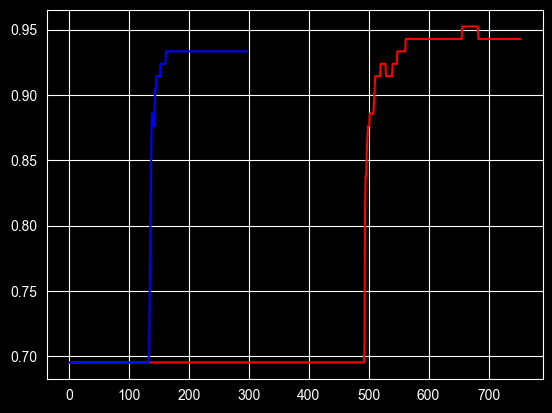

In [29]:
plt.plot(np.arange(1, epoch_count + 1, 1), np.array(evolution_accuracy), color='r')
plt.plot(np.arange(1, f_epoch_count + 1, 1), np.array(f_evolution_accuracy), color='b')

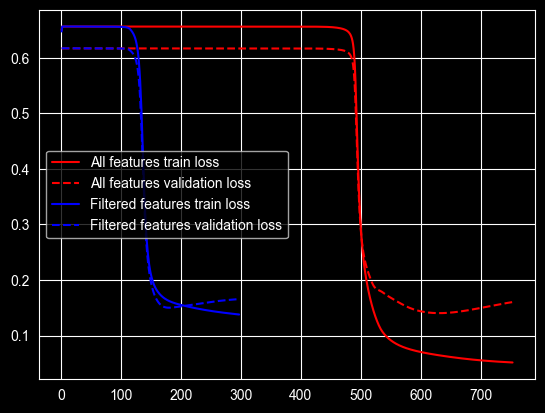

In [30]:
plt.plot(np.arange(1, epoch_count + 1, 1), np.array(evolution_train_loss), 'r')
plt.plot(np.arange(1, epoch_count + 1, 1), np.array(evolution_val_loss), 'r--')
plt.plot(np.arange(1, f_epoch_count + 1, 1), np.array(f_evolution_train_loss), 'b')
plt.plot(np.arange(1, f_epoch_count + 1, 1), np.array(f_evolution_val_loss), 'b--')

plt.legend(['All features train loss', 'All features validation loss', 'Filtered features train loss', 'Filtered features validation loss'])
plt.show()